In [ ]:
#observation 1 - CI provider presence across all apps

In [27]:
from pathlib import Path
import pandas as pd
import numpy as np
import math
from scipy.stats import chi2_contingency

# --- Load ---
p = Path("5_Total_Repo.csv")
if not p.exists():
    p = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv")
df = pd.read_csv(p)

# --- Preprocess ---
df["adopt"] = df["instru_t_ci_signal"].astype(bool)

# Option A: Multi-dev = contributors >= 2 ; Single/Unknown = contributors in {0,1}
df["multi_dev"] = df["contributors"] >= 2
df["team_group"] = np.where(df["multi_dev"], "Multi-dev (>=2)", "Single/Unknown (0–1)")

# --- Table: adoption rate by team group ---
tbl = (
    df.groupby("team_group")["adopt"]
      .agg(repos="count", adopters="sum")
      .reset_index()
)
tbl["rate"] = (tbl["adopters"] / tbl["repos"]) * 100

# Add total row
total = pd.DataFrame([{
    "team_group": "Total",
    "repos": len(df),
    "adopters": int(df["adopt"].sum()),
    "rate": float(df["adopt"].mean() * 100),
}])
tbl_out = pd.concat([tbl, total], ignore_index=True)

print("\n[Observation 1.1] Adoption rate (overall + by team group):")
print(tbl_out.to_string(index=False, formatters={"rate": "{:.2f}%".format}))

# --- χ² test (2x2): Multi-dev vs Adopt ---
cont = pd.crosstab(df["multi_dev"], df["adopt"])
chi2, pval, dof, expected = chi2_contingency(cont, correction=False)  # no Yates
phi = math.sqrt(chi2 / cont.to_numpy().sum())

print("\n[Observation 1.1] Chi-square test (no Yates):")
print("Contingency table (rows=multi_dev False/True, cols=adopt False/True):\n", cont)
print(f"chi2={chi2:.4f}, dof={dof}, p={pval:.6g}, phi={phi:.4f}")





[Observation 1.1] Adoption rate (overall + by team group):
          team_group  repos  adopters   rate
     Multi-dev (>=2)   3714       413 11.12%
Single/Unknown (0–1)    804        68  8.46%
               Total   4518       481 10.65%

[Observation 1.1] Chi-square test (no Yates):
Contingency table (rows=multi_dev False/True, cols=adopt False/True):
 adopt      False  True 
multi_dev              
False        736     68
True        3301    413
chi2=4.9247, dof=1, p=0.0264756, phi=0.0330


In [6]:
#observation 2

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
import math
from scipy.stats import chi2_contingency

# --- Load ---
p = Path("5_Total_Repo.csv")
if not p.exists():
    p = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv")
df = pd.read_csv(p)

df["adopt"] = df["instru_t_ci_signal"].astype(bool)

# --- Helpers ---
def cohen_h(p1, p2):
    """Cohen's h for difference between two proportions."""
    return 2 * (math.asin(math.sqrt(p1)) - math.asin(math.sqrt(p2)))

def odds_ratio(a, b, c, d, add_half_if_zero=True):
    """
    OR for 2x2:
      group1: adopters=a, non=b
      group2: adopters=c, non=d
    """
    if add_half_if_zero and min(a, b, c, d) == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    return (a * d) / (b * c)

def chi2_2x2(a, b, c, d):
    cont = np.array([[a, b], [c, d]])
    chi2, pval, dof, exp = chi2_contingency(cont, correction=False)
    return chi2, pval

def flutter_present(topics):
    """True if topics include 'flutter' or 'flutter-*' token."""
    if pd.isna(topics):
        return False
    toks = [t.strip().lower() for t in str(topics).split(",") if t.strip()]
    return any(tok == "flutter" or tok.startswith("flutter-") for tok in toks)

df["flutter_topic"] = df["topics"].apply(flutter_present)

# --- Language buckets (for table) ---
def lang_bucket(lang):
    if lang in ("Kotlin", "Java", "Dart"):
        return lang
    if lang in ("JavaScript", "TypeScript"):
        return "JavaScript/TypeScript"
    if lang in ("C", "C++", "Objective-C", "Objective-C++"):
        return "C/C++ (incl ObjC)"
    return "Other"

df["lang_bucket"] = df["language"].apply(lang_bucket)

# --- Table: adoption by language bucket ---
lang_tbl = (
    df.groupby("lang_bucket")["adopt"]
      .agg(repos="count", adopters="sum")
      .reset_index()
)
lang_tbl["rate"] = (lang_tbl["adopters"] / lang_tbl["repos"]) * 100
lang_tbl = lang_tbl.sort_values("repos", ascending=False)

print("\n[Observation 1.2] Adoption by language bucket:")
print(lang_tbl.to_string(index=False, formatters={"rate": "{:.2f}%".format}))

# --- Test 1: (Kotlin+Java) vs Dart ---
g_native = df["language"].isin(["Kotlin", "Java"])
g_dart = df["language"].eq("Dart")
sub = df[g_native | g_dart].copy()

a = int(sub[g_native & (sub["adopt"])].shape[0])  # native adopters
b = int(sub[g_native & (~sub["adopt"])].shape[0]) # native non
c = int(sub[g_dart & (sub["adopt"])].shape[0])    # dart adopters
d = int(sub[g_dart & (~sub["adopt"])].shape[0])   # dart non

p_native = a / (a + b)
p_dart = c / (c + d)
chi2, pval = chi2_2x2(a, b, c, d)
h = cohen_h(p_native, p_dart)
OR = odds_ratio(a, b, c, d)

print("\n[Observation 1.2] Kotlin+Java vs Dart (2x2):")
print(f"Counts: native adopt={a}, native non={b}, dart adopt={c}, dart non={d}")
print(f"Rates:  native={p_native:.4%}, dart={p_dart:.4%}")
print(f"chi2={chi2:.4f}, p={pval:.6g}")
print(f"Cohen's h={h:.4f} (sign shows direction), OR={OR:.4f} (native vs dart)")

# --- Test 2: Flutter topic present vs absent ---
a = int(df[df["flutter_topic"] & df["adopt"]].shape[0])
b = int(df[df["flutter_topic"] & (~df["adopt"])].shape[0])
c = int(df[(~df["flutter_topic"]) & df["adopt"]].shape[0])
d = int(df[(~df["flutter_topic"]) & (~df["adopt"])].shape[0])

p_flutter = a / (a + b)
p_nonflutter = c / (c + d)
chi2, pval = chi2_2x2(a, b, c, d)
# report h in the direction (non-flutter minus flutter) if you prefer:
h_non_minus_flutter = cohen_h(p_nonflutter, p_flutter)
OR_non_vs_flutter = odds_ratio(c, d, a, b)  # odds(non) / odds(flutter)

print("\n[Observation 1.2] Flutter topic present vs absent (2x2):")
print(f"Counts: flutter adopt={a}, flutter non={b}, nonflutter adopt={c}, nonflutter non={d}")
print(f"Rates:  flutter={p_flutter:.4%}, non-flutter={p_nonflutter:.4%}")
print(f"chi2={chi2:.4f}, p={pval:.6g}")
print(f"Cohen's h (non - flutter)={h_non_minus_flutter:.4f}, OR(non vs flutter)={OR_non_vs_flutter:.4f}")





[Observation 1.2] Adoption by language bucket:
          lang_bucket  repos  adopters   rate
               Kotlin   1523       203 13.33%
                 Java   1363       183 13.43%
                 Dart    746        27  3.62%
    C/C++ (incl ObjC)    365        10  2.74%
JavaScript/TypeScript    319        35 10.97%
                Other    202        23 11.39%

[Observation 1.2] Kotlin+Java vs Dart (2x2):
Counts: native adopt=386, native non=2500, dart adopt=27, dart non=719
Rates:  native=13.3749%, dart=3.6193%
chi2=55.9782, p=7.32794e-14
Cohen's h=0.3660 (sign shows direction), OR=4.1116 (native vs dart)

[Observation 1.2] Flutter topic present vs absent (2x2):
Counts: flutter adopt=21, flutter non=529, nonflutter adopt=460, nonflutter non=3508
Rates:  flutter=3.8182%, non-flutter=11.5927%
chi2=30.6922, p=3.02374e-08
Cohen's h (non - flutter)=0.3015, OR(non vs flutter)=3.3032


C:\Users\gilla\AppData\Local\Temp\ipykernel_39008\1170170861.py:73: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  a = int(sub[g_native & (sub["adopt"])].shape[0])  # native adopters
C:\Users\gilla\AppData\Local\Temp\ipykernel_39008\1170170861.py:74: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  b = int(sub[g_native & (~sub["adopt"])].shape[0]) # native non
C:\Users\gilla\AppData\Local\Temp\ipykernel_39008\1170170861.py:75: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c = int(sub[g_dart & (sub["adopt"])].shape[0])    # dart adopters
C:\Users\gilla\AppData\Local\Temp\ipykernel_39008\1170170861.py:76: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  d = int(sub[g_dart & (~sub["adopt"])].shape[0])   # dart non


In [7]:
#observation 3

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# --- Load ---
p = Path("5_Total_Repo.csv")
if not p.exists():
    p = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv")
df = pd.read_csv(p)

df["adopt"] = df["instru_t_ci_signal"].astype(bool)

ad = df[df["adopt"]].copy()
non = df[~df["adopt"]].copy()

def cliffs_delta_from_u(U, nx, ny):
    """
    Cliff's delta using MWU U statistic:
      delta = 2*U/(nx*ny) - 1
    SciPy's MWU uses tie handling equivalent to 0.5 for ties in U.
    """
    return 2 * U / (nx * ny) - 1

metrics = [
    ("pull_requests", "Pull requests"),
    ("commits_GitAPI", "Commits (GitAPI)"),
    ("contributors", "Contributors"),
    ("repo_age", "Repo age (years)"),
    ("open_issues_count", "Open issues"),
]

rows = []
for col, label in metrics:
    x = ad[col].dropna().to_numpy()
    y = non[col].dropna().to_numpy()

    # One-sided test: adopters > non-adopters
    res = mannwhitneyu(x, y, alternative="greater", method="auto")
    U = res.statistic
    pval = res.pvalue
    nx, ny = len(x), len(y)

    delta = cliffs_delta_from_u(U, nx, ny)
    rows.append({
        "Metric (A > N)": label,
        "Median (A)": float(np.median(x)),
        "Median (N)": float(np.median(y)),
        "p (1-sided)": pval,
        "Cliff's δ": float(delta),
        "nA": nx,
        "nN": ny,
    })

out = pd.DataFrame(rows)
print("\n[Observation 1.3] MWU (one-sided, A>N) + Cliff's δ:")
print(out.to_string(index=False))







[Observation 1.3] MWU (one-sided, A>N) + Cliff's δ:
  Metric (A > N)  Median (A)  Median (N)  p (1-sided)  Cliff's δ  nA   nN
   Pull requests       68.00        24.0 2.294925e-16   0.226100 481 4037
Commits (GitAPI)      389.00       243.0 3.920947e-09   0.160758 481 4037
    Contributors        7.00         5.0 5.212288e-07   0.135415 481 4037
Repo age (years)        7.44         5.6 2.278996e-14   0.210117 481 4037
     Open issues       16.00        10.0 1.620773e-07   0.142146 481 4037


In [ ]:
#observation 3 - beanplot

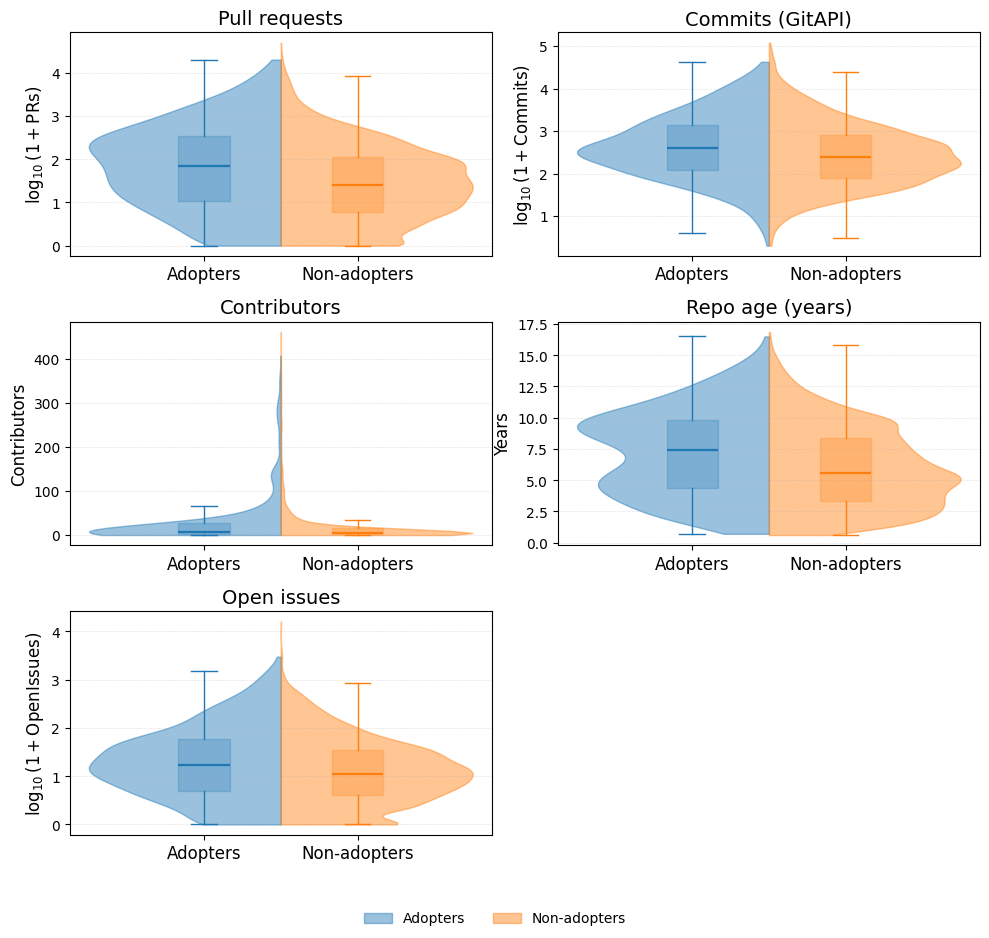

In [35]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv"

ADOPTER_COLOR = "C0"
NONADOPTER_COLOR = "C1"

# ============================================================
# Load dataset
# ============================================================
p = Path(CSV_PATH)
if not p.exists():
    raise FileNotFoundError(f"CSV not found at: {p}")

df = pd.read_csv(p)
df["adopt"] = df["instru_t_ci_signal"].astype(bool)

# ============================================================
# Helpers
# ============================================================
def pick_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns exist: {candidates}")

def transform_series(x: pd.Series, mode: str | None):
    x = pd.to_numeric(x, errors="coerce").dropna().to_numpy()
    if mode is None:
        return x
    if mode == "log10p1":
        return np.log10(1.0 + np.clip(x, a_min=0, a_max=None))
    raise ValueError(f"Unknown transform mode: {mode}")

def split_violin_with_box(
    ax, data_left, data_right, title, y_label,
    center=1.0, width=0.9, box_offset=0.18, box_width=0.12,
    left_color=ADOPTER_COLOR, right_color=NONADOPTER_COLOR, alpha=0.45
):
 
    vp = ax.violinplot(
        [data_left, data_right],
        positions=[center, center],
        widths=width,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    bodies = vp["bodies"]
    if len(bodies) >= 2:
        # Left (Adopters)
        body_L = bodies[0]
        body_L.set_facecolor(left_color)
        body_L.set_edgecolor(left_color)
        body_L.set_alpha(alpha)
        verts = body_L.get_paths()[0].vertices
        verts[verts[:, 0] > center, 0] = center  # clip to left half

        # Right (Non-adopters)
        body_R = bodies[1]
        body_R.set_facecolor(right_color)
        body_R.set_edgecolor(right_color)
        body_R.set_alpha(alpha)
        verts = body_R.get_paths()[0].vertices
        verts[verts[:, 0] < center, 0] = center  # clip to right half

    # Boxplots overlay (offset left/right) with matching colors
    ax.boxplot(
        [data_left],
        positions=[center - box_offset],
        widths=box_width,
        showfliers=False,
        manage_ticks=False,
        patch_artist=True,
        boxprops=dict(facecolor=left_color, edgecolor=left_color, alpha=0.25),
        whiskerprops=dict(color=left_color),
        capprops=dict(color=left_color),
        medianprops=dict(color=left_color, linewidth=1.6),
    )
    ax.boxplot(
        [data_right],
        positions=[center + box_offset],
        widths=box_width,
        showfliers=False,
        manage_ticks=False,
        patch_artist=True,
        boxprops=dict(facecolor=right_color, edgecolor=right_color, alpha=0.25),
        whiskerprops=dict(color=right_color),
        capprops=dict(color=right_color),
        medianprops=dict(color=right_color, linewidth=1.6),
    )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel(y_label,fontsize=12)
    ax.set_xticks([center - box_offset, center + box_offset])
    ax.set_xticklabels(["Adopters", "Non-adopters"], fontsize=12)
    ax.grid(True, axis="y", linestyle=":", linewidth=0.5, alpha=0.6)

# ============================================================
# Column selection (robust)
# ============================================================
col_pr  = pick_col(df, ["pull_requests", "pull_request", "prs", "num_pull_requests"])
col_cm  = pick_col(df, ["commits_GitAPI", "commits", "num_commits"])
col_con = pick_col(df, ["contributors", "num_contributors"])
col_age = pick_col(df, ["repo_age", "age_years", "repository_age_years"])
col_iss = pick_col(df, ["open_issues_count", "open_issues", "issues_open"])

metrics = [
    (col_pr,  "Pull requests",        "log10p1", r"$\log_{10}(1+\mathrm{PRs})$"),
    (col_cm,  "Commits (GitAPI)",     "log10p1", r"$\log_{10}(1+\mathrm{Commits})$"),
    (col_con, "Contributors",         None,     "Contributors"),
    (col_age, "Repo age (years)",     None,     "Years"),
    (col_iss, "Open issues",          "log10p1", r"$\log_{10}(1+\mathrm{OpenIssues})$"),
]

A = df[df["adopt"]]
N = df[~df["adopt"]]

# ============================================================
# Plot: max 2 plots per row
# ============================================================
n_plots = len(metrics)
ncols = 2
nrows = math.ceil(n_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.2 * nrows))
axes = np.array(axes).reshape(-1)  # flatten robustly

for i, (col, title, tmode, ylab) in enumerate(metrics):
    a_vals = transform_series(A[col], tmode)
    n_vals = transform_series(N[col], tmode)
    split_violin_with_box(
        axes[i],
        a_vals,
        n_vals,
        title=title,
        y_label=ylab,
        center=1.0,
        width=0.9,
        box_offset=0.18,
        box_width=0.12,
        left_color=ADOPTER_COLOR,
        right_color=NONADOPTER_COLOR,
        alpha=0.45
    )

# Turn off any unused axes
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

# Legend at bottom
handles = [
    Patch(facecolor=ADOPTER_COLOR, edgecolor=ADOPTER_COLOR, alpha=0.45, label="Adopters"),
    Patch(facecolor=NONADOPTER_COLOR, edgecolor=NONADOPTER_COLOR, alpha=0.45, label="Non-adopters"),
]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False)

# Leave space at bottom for legend
fig.tight_layout(rect=[0, 0.06, 1, 0.98])

plt.show()


In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import math
from scipy.stats import chi2_contingency

# --- Load ---
p = Path("5_Total_Repo.csv")
if not p.exists():
    p = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\5_Total_Repo.csv")
df = pd.read_csv(p)

df["adopt"] = df["instru_t_ci_signal"].astype(bool)

# Provider columns in this dataset
provider_cols = [
    "github_actions", "travis_ci", "circle_ci", "gitlab",
    "appveyor", "azure_pipelines", "cirrus", "bitrise"
]
# (If you want all provider columns available in the file:)
all_provider_cols = [
    "appveyor", "azure_pipelines", "bitbucket", "bitrise", "circle_ci",
    "cirrus", "codemagic", "github_actions", "gitlab", "semaphore", "travis_ci"
]

def chi2_phi_2x2(a, b, c, d):
    cont = np.array([[a, b], [c, d]])
    chi2, pval, dof, exp = chi2_contingency(cont, correction=False)  # no Yates
    phi = math.sqrt(chi2 / cont.sum())
    return chi2, pval, phi

rows = []
A = df[df["adopt"]]
N = df[~df["adopt"]]

for col in provider_cols:
    a = int((A[col].fillna(0) > 0).sum())  # adopters with provider
    b = int((A[col].fillna(0) <= 0).sum()) # adopters without provider
    c = int((N[col].fillna(0) > 0).sum())  # non-adopters with provider
    d = int((N[col].fillna(0) <= 0).sum()) # non-adopters without provider

    chi2, pval, phi = chi2_phi_2x2(a, b, c, d)

    rows.append({
        "Provider": col,
        "Adopters (count)": a,
        "Adopters (%)": 100 * a / len(A),
        "Non-adopters (count)": c,
        "Non-adopters (%)": 100 * c / len(N),
        "p (chi2)": pval,
        "phi": phi,
    })

prov_tbl = pd.DataFrame(rows)
print("\n[Observation 1.4] Provider footprint (binary presence per repo):")
print(prov_tbl.to_string(index=False, formatters={
    "Adopters (%)": "{:.2f}%".format,
    "Non-adopters (%)": "{:.2f}%".format,
    "p (chi2)": "{:.6g}".format,
    "phi": "{:.4f}".format
}))

# --- Single-provider share (binary presence across ALL providers) ---
presence = (df[all_provider_cols].fillna(0) > 0).astype(int)
df["n_providers"] = presence.sum(axis=1)

single = int((df["n_providers"] == 1).sum())
total = len(df)
print("\nSingle CI provider (binary presence across all known providers):")
print(f"{single}/{total} = {single/total:.2%}")





[Observation 1.4] Provider footprint (binary presence per repo):
       Provider  Adopters (count) Adopters (%)  Non-adopters (count) Non-adopters (%)   p (chi2)    phi
 github_actions               319       66.32%                  2939           72.80% 0.00273284 0.0446
      travis_ci               149       30.98%                  1026           25.41% 0.00857196 0.0391
      circle_ci                42        8.73%                   231            5.72%  0.0088269 0.0390
         gitlab                12        2.49%                    91            2.25%   0.738184 0.0050
       appveyor                 5        1.04%                   102            2.53%  0.0426104 0.0302
azure_pipelines                 4        0.83%                    31            0.77%   0.880265 0.0022
         cirrus                 3        0.62%                    20            0.50%   0.708632 0.0056
        bitrise                 3        0.62%                     6            0.15%  0.0271815 0.032